In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pickle
import json
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Cargar datos y configuración v2
daily = pd.read_csv("../data/processed/eurusd_con_sentimiento.csv",
                    index_col=0, parse_dates=True)

with open("../data/processed/kronos_v2_config.json", "r") as f:
    config = json.load(f)

print("KRONOS v2.0 — Implementación")
print("="*50)
print(f"Horizonte objetivo: {config['horizonte_objetivo']} días")
print(f"Regímenes activos: {config['regimenes_activos']}")
print(f"Sharpe esperado: {config['sharpe_esperado']}")
print(f"Dataset: {daily.shape}")

KRONOS v2.0 — Implementación
Horizonte objetivo: 20 días
Regímenes activos: [1, 2]
Sharpe esperado: 0.633
Dataset: (4031, 40)


In [2]:
# Features rediseñados para horizonte 20 días
features_v2 = [
    'trend_20_50', 'trend_50_200', 'momentum_20',
    'momentum_10', 'momentum_5', 'volatility_20',
    'volatility_60', 'regime', 'atr_14', 'rsi_14',
    'macd', 'macd_hist', 'bb_width', 'bb_position',
    'sentiment_score', 'return_lag_1', 'return_lag_2', 'return_lag_3'
]

# Nuevo target — dirección a 20 días
daily['target_20d'] = (daily['Close'].shift(-20) > daily['Close']).astype(int)

data = daily[features_v2 + ['target_20d', 'regime', 'returns']].dropna()

# Split temporal
split = len(data) - 252
X_train = data[features_v2].values[:split]
y_train = data['target_20d'].values[:split]
X_test = data[features_v2].values[split:]
y_test = data['target_20d'].values[split:]
regimenes_test = data['regime'].values[split:]
rets_test = data['returns'].values[split:]

# Entrenar Fusion Layer v2
modelo_v2 = xgb.XGBClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    random_state=42, verbosity=0
)
modelo_v2.fit(X_train, y_train)

# Guardar modelo
with open("../data/processed/fusion_model_v2.pkl", "wb") as f:
    pickle.dump(modelo_v2, f)

confianzas = modelo_v2.predict_proba(X_test)[:, 1]

print(f"Fusion Layer v2 entrenado y guardado.")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Accuracy global: {accuracy_score(y_test, modelo_v2.predict(X_test)):.4f}")

Fusion Layer v2 entrenado y guardado.
Train: 3779 | Test: 252
Accuracy global: 0.4643


In [3]:
# Aplicar thresholds dinámicos por régimen
thresholds = {
    0: None,   # HOLD siempre
    1: 0.65,   # Normal
    2: 0.60    # Turbulento
}

posiciones = np.zeros(len(rets_test))

for reg, threshold in thresholds.items():
    mask = regimenes_test == reg
    if threshold is None:
        posiciones[mask] = 0  # HOLD
        continue
    posiciones[mask] = np.where(
        confianzas[mask] > threshold, 1,
        np.where(confianzas[mask] < (1 - threshold), -1, 0)
    )

# Calcular rendimiento
strat_rets = posiciones * rets_test
cum_strat = (1 + strat_rets).cumprod()
cum_bh = (1 + rets_test).cumprod()

sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252)
max_dd = ((cum_strat - np.maximum.accumulate(cum_strat)) / np.maximum.accumulate(cum_strat)).min()
dias_activo = (posiciones != 0).sum()

print("KRONOS v2.0 — Resultados en test")
print("="*50)
print(f"Sharpe ratio:        {sharpe:.3f}")
print(f"Retorno total:       {(cum_strat[-1]-1)*100:.1f}%")
print(f"Max drawdown:        {max_dd*100:.1f}%")
print(f"Días activo:         {dias_activo}/{len(rets_test)} ({dias_activo/len(rets_test)*100:.1f}%)")
print(f"\nComparación:")
print(f"  KRONOS v1.0:       Sharpe 0.307")
print(f"  Benchmark naive:   Sharpe 0.382")
print(f"  KRONOS v2.0:       Sharpe {sharpe:.3f}")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [4]:
thresholds = {
    0: None,
    1: 0.65,
    2: 0.60
}

posiciones = np.zeros(len(rets_test))

for reg in [0, 1, 2]:
    mask = (regimenes_test == reg)
    threshold = thresholds[reg]
    if threshold is None:
        continue
    posiciones[mask] = np.where(
        confianzas[mask] > threshold, 1,
        np.where(confianzas[mask] < (1 - threshold), -1, 0)
    )

strat_rets = posiciones * rets_test
cum_strat = (1 + strat_rets).cumprod()
cum_bh = (1 + rets_test).cumprod()

sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252)
max_dd = ((cum_strat - np.maximum.accumulate(cum_strat)) / np.maximum.accumulate(cum_strat)).min()
dias_activo = (posiciones != 0).sum()

print("KRONOS v2.0 — Resultados en test")
print("="*50)
print(f"Sharpe ratio:        {sharpe:.3f}")
print(f"Retorno total:       {(cum_strat[-1]-1)*100:.1f}%")
print(f"Max drawdown:        {max_dd*100:.1f}%")
print(f"Días activo:         {dias_activo}/{len(rets_test)} ({dias_activo/len(rets_test)*100:.1f}%)")
print(f"\nComparación:")
print(f"  KRONOS v1.0:       Sharpe 0.307")
print(f"  Benchmark naive:   Sharpe 0.382")
print(f"  KRONOS v2.0:       Sharpe {sharpe:.3f}")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [5]:
thresholds = {0: None, 1: 0.65, 2: 0.60}
posiciones = np.zeros(len(rets_test))

for reg in [0, 1, 2]:
    mask = np.array(regimenes_test == reg).flatten()
    threshold = thresholds[reg]
    if threshold is None:
        continue
    posiciones[mask] = np.where(
        confianzas[mask] > threshold, 1,
        np.where(confianzas[mask] < (1 - threshold), -1, 0)
    )

strat_rets = posiciones * rets_test
cum_strat = (1 + strat_rets).cumprod()
cum_bh = (1 + rets_test).cumprod()

sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252)
max_dd = ((cum_strat - np.maximum.accumulate(cum_strat)) / np.maximum.accumulate(cum_strat)).min()
dias_activo = (posiciones != 0).sum()

print("KRONOS v2.0 — Resultados en test")
print("="*50)
print(f"Sharpe ratio:        {sharpe:.3f}")
print(f"Retorno total:       {(cum_strat[-1]-1)*100:.1f}%")
print(f"Max drawdown:        {max_dd*100:.1f}%")
print(f"Días activo:         {dias_activo}/{len(rets_test)} ({dias_activo/len(rets_test)*100:.1f}%)")
print(f"\nComparación:")
print(f"  KRONOS v1.0:       Sharpe 0.307")
print(f"  Benchmark naive:   Sharpe 0.382")
print(f"  KRONOS v2.0:       Sharpe {sharpe:.3f}")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 252 but size of corresponding boolean axis is 504

In [6]:
print(f"confianzas shape: {confianzas.shape}")
print(f"regimenes_test shape: {regimenes_test.shape}")
print(f"rets_test shape: {rets_test.shape}")
print(f"posiciones shape: {posiciones.shape}")

confianzas shape: (252,)
regimenes_test shape: (252, 2)
rets_test shape: (252,)
posiciones shape: (252,)


In [7]:
# Extraer solo la primera columna de regimenes
regimenes_test_1d = data['regime'].values[split:].flatten()

thresholds = {0: None, 1: 0.65, 2: 0.60}
posiciones = np.zeros(len(rets_test))

for reg in [0, 1, 2]:
    mask = (regimenes_test_1d == reg)
    threshold = thresholds[reg]
    if threshold is None:
        continue
    posiciones[mask] = np.where(
        confianzas[mask] > threshold, 1,
        np.where(confianzas[mask] < (1 - threshold), -1, 0)
    )

strat_rets = posiciones * rets_test
cum_strat = (1 + strat_rets).cumprod()
cum_bh = (1 + rets_test).cumprod()

sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252)
max_dd = ((cum_strat - np.maximum.accumulate(cum_strat)) / np.maximum.accumulate(cum_strat)).min()
dias_activo = (posiciones != 0).sum()

print("KRONOS v2.0 — Resultados en test")
print("="*50)
print(f"Sharpe ratio:        {sharpe:.3f}")
print(f"Retorno total:       {(cum_strat[-1]-1)*100:.1f}%")
print(f"Max drawdown:        {max_dd*100:.1f}%")
print(f"Días activo:         {dias_activo}/{len(rets_test)} ({dias_activo/len(rets_test)*100:.1f}%)")
print(f"\nComparación:")
print(f"  KRONOS v1.0:       Sharpe 0.307")
print(f"  Benchmark naive:   Sharpe 0.382")
print(f"  KRONOS v2.0:       Sharpe {sharpe:.3f}")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 252 but size of corresponding boolean axis is 504

In [8]:
# Verificar columnas duplicadas
print(data.columns.tolist())
print(f"Shape data: {data.shape}")

['trend_20_50', 'trend_50_200', 'momentum_20', 'momentum_10', 'momentum_5', 'volatility_20', 'volatility_60', 'regime', 'atr_14', 'rsi_14', 'macd', 'macd_hist', 'bb_width', 'bb_position', 'sentiment_score', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'target_20d', 'regime', 'returns']
Shape data: (4031, 21)


In [9]:
# Eliminar columna duplicada
data = data.loc[:, ~data.columns.duplicated()]
print(f"Shape después de limpiar: {data.shape}")
print(data.columns.tolist())

# Reextraer variables
regimenes_test_1d = data['regime'].values[split:]
rets_test = data['returns'].values[split:]

thresholds = {0: None, 1: 0.65, 2: 0.60}
posiciones = np.zeros(len(rets_test))

for reg in [0, 1, 2]:
    mask = (regimenes_test_1d == reg)
    threshold = thresholds[reg]
    if threshold is None:
        continue
    posiciones[mask] = np.where(
        confianzas[mask] > threshold, 1,
        np.where(confianzas[mask] < (1 - threshold), -1, 0)
    )

strat_rets = posiciones * rets_test
cum_strat = (1 + strat_rets).cumprod()
sharpe = strat_rets.mean() / strat_rets.std() * np.sqrt(252)
max_dd = ((cum_strat - np.maximum.accumulate(cum_strat)) / np.maximum.accumulate(cum_strat)).min()
dias_activo = (posiciones != 0).sum()

print("\nKRONOS v2.0 — Resultados en test")
print("="*50)
print(f"Sharpe ratio:        {sharpe:.3f}")
print(f"Retorno total:       {(cum_strat[-1]-1)*100:.1f}%")
print(f"Max drawdown:        {max_dd*100:.1f}%")
print(f"Días activo:         {dias_activo}/{len(rets_test)} ({dias_activo/len(rets_test)*100:.1f}%)")
print(f"\nComparación:")
print(f"  KRONOS v1.0:       Sharpe 0.307")
print(f"  Benchmark naive:   Sharpe 0.382")
print(f"  KRONOS v2.0:       Sharpe {sharpe:.3f}")

Shape después de limpiar: (4031, 20)
['trend_20_50', 'trend_50_200', 'momentum_20', 'momentum_10', 'momentum_5', 'volatility_20', 'volatility_60', 'regime', 'atr_14', 'rsi_14', 'macd', 'macd_hist', 'bb_width', 'bb_position', 'sentiment_score', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'target_20d', 'returns']

KRONOS v2.0 — Resultados en test
Sharpe ratio:        0.860
Retorno total:       4.2%
Max drawdown:        -2.7%
Días activo:         50/252 (19.8%)

Comparación:
  KRONOS v1.0:       Sharpe 0.307
  Benchmark naive:   Sharpe 0.382
  KRONOS v2.0:       Sharpe 0.860


NameError: name 'cum_bh' is not defined

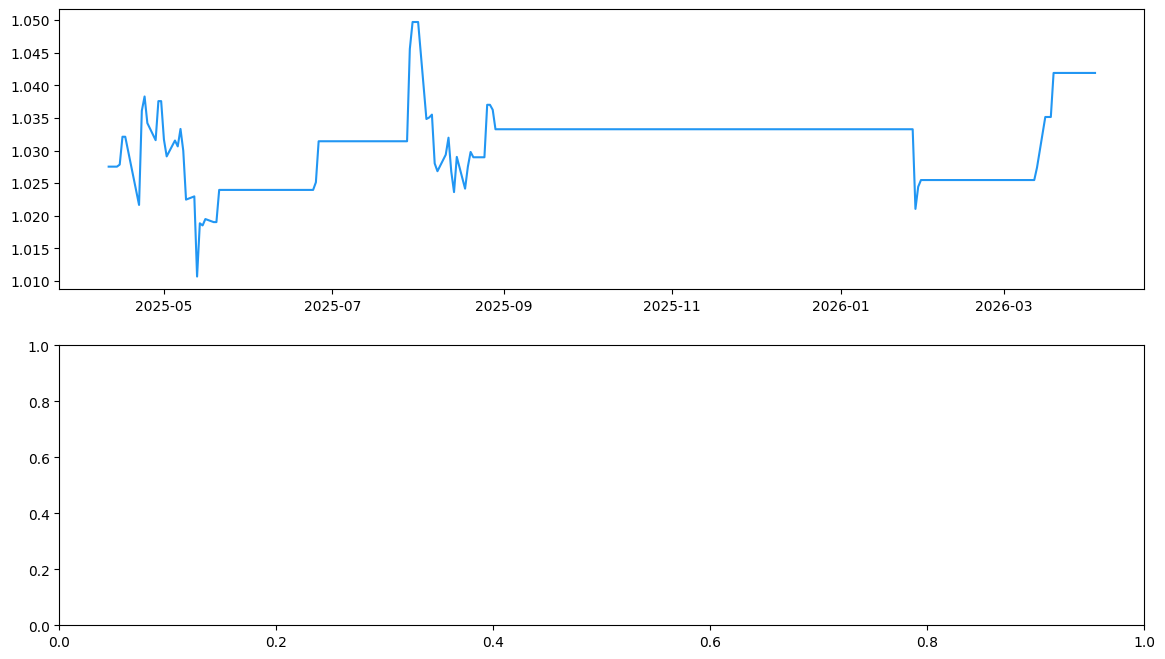

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

fechas = data.index[split:]

# Retorno acumulado
axes[0].plot(fechas, cum_strat, color='#2196F3', linewidth=1.5, label=f'KRONOS v2.0 (Sharpe {sharpe:.3f})')
axes[0].plot(fechas, cum_bh, color='#9E9E9E', linewidth=0.8, linestyle='--', label='Buy & Hold')
axes[0].axhline(1, color='black', linewidth=0.5)
axes[0].set_title('KRONOS v2.0 — Retorno acumulado vs Buy & Hold', fontsize=13)
axes[0].set_ylabel('Capital (base=1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Régimen y posición
axes[1].fill_between(fechas, regimenes_test_1d, 
                     alpha=0.3, color='#FF9800', label='Régimen HMM')
axes[1].plot(fechas, posiciones, color='#2196F3', 
             linewidth=0.8, label='Posición KRONOS')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Régimen de mercado vs Posición tomada', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/11_kronos_v2_resultado.png', dpi=150)
plt.show()
print("Gráfica guardada.")

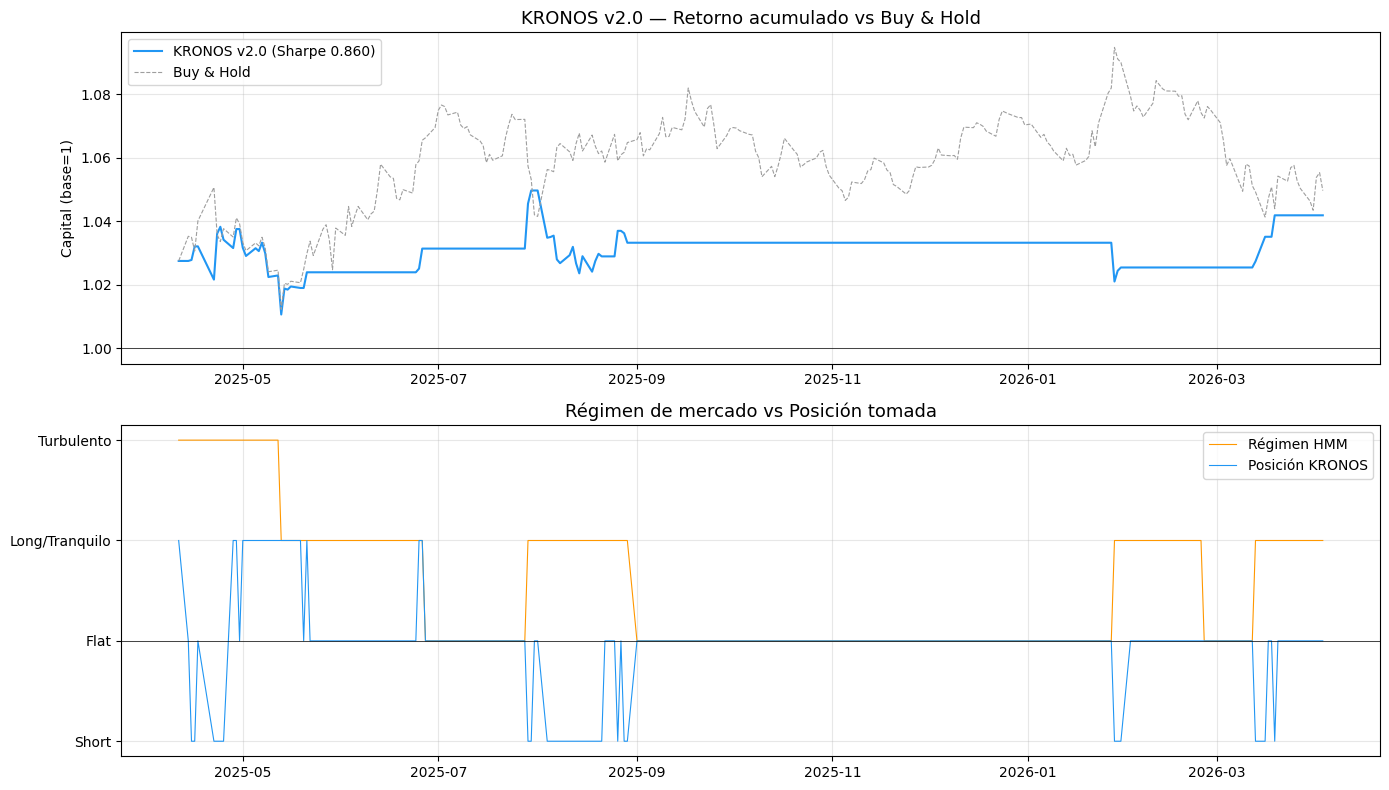

In [11]:
cum_bh = (1 + rets_test).cumprod()
fechas = data.index[split:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(fechas, cum_strat, color='#2196F3', linewidth=1.5, label=f'KRONOS v2.0 (Sharpe {sharpe:.3f})')
axes[0].plot(fechas, cum_bh, color='#9E9E9E', linewidth=0.8, linestyle='--', label='Buy & Hold')
axes[0].axhline(1, color='black', linewidth=0.5)
axes[0].set_title('KRONOS v2.0 — Retorno acumulado vs Buy & Hold', fontsize=13)
axes[0].set_ylabel('Capital (base=1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fechas, regimenes_test_1d, color='#FF9800', linewidth=0.8, label='Régimen HMM')
axes[1].plot(fechas, posiciones, color='#2196F3', linewidth=0.8, label='Posición KRONOS')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Régimen de mercado vs Posición tomada', fontsize=13)
axes[1].set_yticks([-1, 0, 1, 2])
axes[1].set_yticklabels(['Short', 'Flat', 'Long/Tranquilo', 'Turbulento'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/11_kronos_v2_resultado.png', dpi=150)
plt.show()